<a href="https://colab.research.google.com/github/yunju-1118/ESAA/blob/OB/ESAA_week11_2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **합성곱 신경망**

## **1. 합성곱 신경망**

합성곱 신경망은 이미지 전체를 한 번에 계산하는 것이 아닌 이미지의 국소적 부분을 계산함으로써 시간과 자원을 절약하여 이미지의 세밀한 부분까지 분석할 수 있는 신경망이다.

### **1.1. 합성곱층의 필요성**

합성곱 신경망은 이미지나 영상을 처리하는 데 유용하다. 이미지 분석은 배열을 펼쳐서 각 픽셀에 가중치를 곱하여 은닉층으로 전달하는데 이 과정에서 공간적 구조를 무시하게 된다. 이를 방지하려고 도입된 것이 합성곱층이다.

### **1.2. 합성곱 신경망 구조**

합성곱 신경망(CNN)은 음성 인식이나 이미지/영상 인식에서 주로 사용되는 신경망이다. 다차원 배열 데이터를 처리하도록 구성되어 컬러이미지 같은 다차원 배열 처리에 특화되어 있으며, 다음과 같이 계층 다섯 개로 구성된다.

1. 입력층
2. 합성곱층
3. 풀링층
4. 완전연결층
5. 출력층



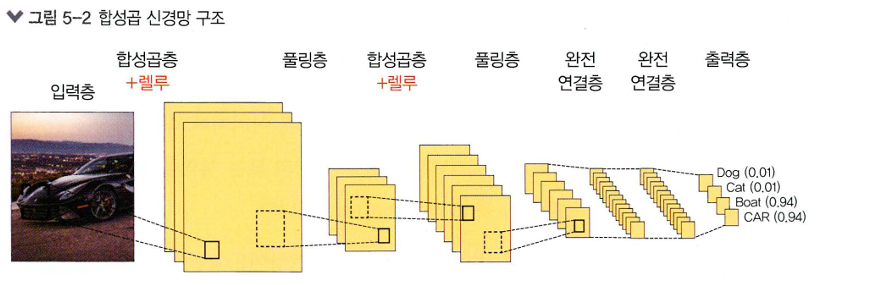

합성곱 신경망은 합성곱층과 풀링층을 거치면서 입력 이미지의 주요 특성 벡터를 추출한다. 그 후 추출된 주요 특성 벡터들은 완전연결층을 거치면서 1차원 벡터로 변환되며, 마지막으로 출력층에서 활성화 함수인 소프트맥스 함수를 사용하여 최종 결과가 출력된다.

**입력층**

입력층은 입력 이미지 데이터가 최초로 거치게 되는 계층이다. 높이, 너비, 채널의 값을 갖는 3차원 데이터이다.

**합성곱층**

합성곱층은 입력 데이터에서 특성을 추출하는 역할을 수행한다.

입력 이미지가 들어왔을 때 이미지에 대한 특성을 감지하기 위해 커널이나 필터를 사용한다. 커널/필터는 이미지의 모든 영역을 훑으면서 특성을 추출하게 되는데, 이렇게 추출된 결과물이 특성 맵이다.

- **입력 데이터**: $W_1 * H_1 * D_1$ ($W_1$: 가로, $H_1$: 세로, $D_1$: 채널)
- **하이퍼 파라미터**
    - 필터 개수: $K$
    - 필터 크기: $F$
    - 스트라이드: $S$
    - 패딩: $P$

- **출력 데이터**

    - $W_2 = (W_1-F+2P)/S+1$
    - $H_2 = (H_1-F+2P)/S+1$
    - $D_2 = K$

**풀링층**

풀링층은 합성곱층과 유사하게 특성 맵의 차원을 다운 샘플링하여 연산량을 감소시키고, 주요한 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 한다.

- **최대 풀링**: 대상 영역에서 최댓값을 추출
- **평균 풀링**: 대상 영역에서 평균을 반환

최대 평균과 평균 풀링을 요악하면 다음과 같다.

- **입력 데이터**: $W_1 * H_1 * D_1$
- **하이퍼 파라미터**
    - 필터 크기: $F$
    - 스트라이드: $S$

- **출력 데이터**

    - $W_2 = (W_1-F)/S+1$
    - $H_2 = (H_1-F)/S+1$
    - $D_2 = D_1$

**완전 연결층**

합성곱층과 풀링층을 거치면서 차원이 축소된 특성 맵은 최종적으로 완전연결층으로 전달된다. 이 과정에서 이미지는 3차원 벡터에서 1차원 벡터로 펼쳐지게 된다.

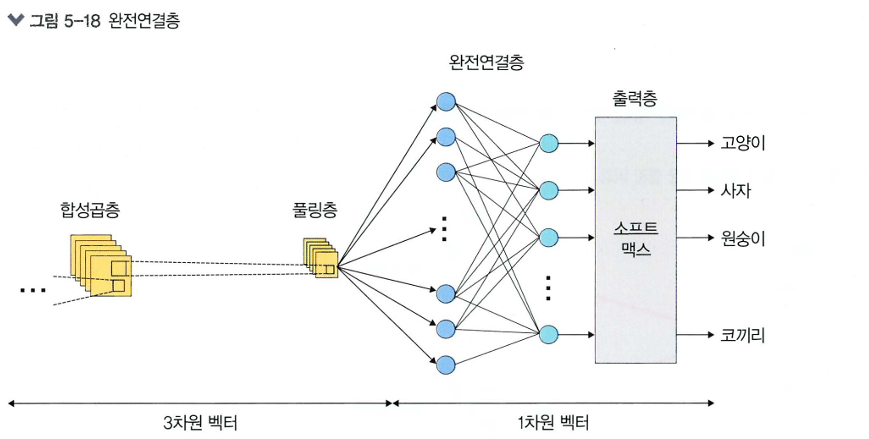

**출력층**

출력층에서는 소프트맥스 활성화 함수가 사용되는데, 입력받은 값을 0~1 사이의 값으로 출력한다. 따라서, 마지막 출력층의 소프트맥스 함수를 사용하여 이미지가 각 레이블에 속할 확률 값이 출력되며, 이때 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정된다.

### **1.3. 1D, 2D, 3D 합성곱**

**1D 합성곱**

1D 합성곱은 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱이다.

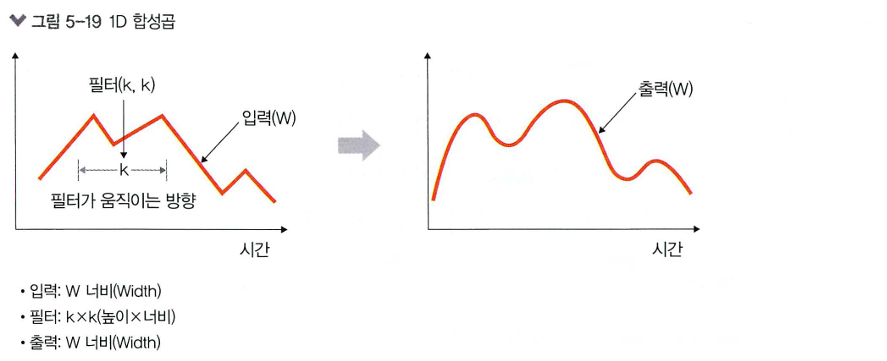

**2D 합성곱**

2D 합성곱은 필터가 다음 그림과 같이 방향 두 개로 움직이는 형태이다. 즉, 입력과 필터에 대한 출력은 (W,H)가 되며, 출력 형태는 2D 행렬이 된다.

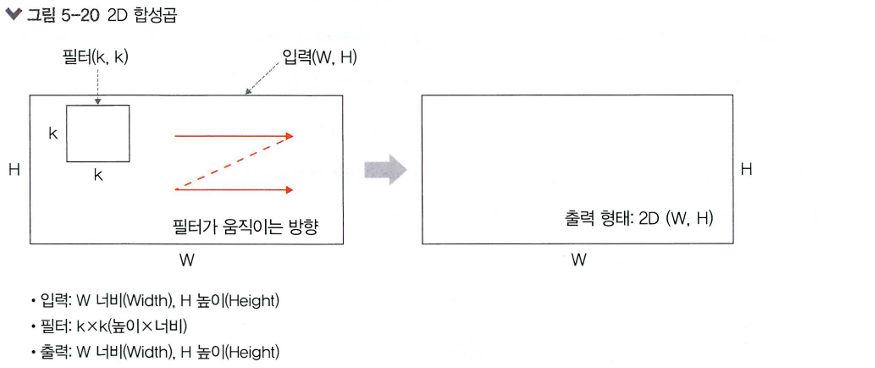

**3D 합성곱**

3D 합성곱은 필터가 움직이는 방향이 세 개가 있다. 입력(W,H,L)에 대해 필터를 적용하면 출력으로 (W,H,L)을 갖는 형태가 3D 합성곱이다.

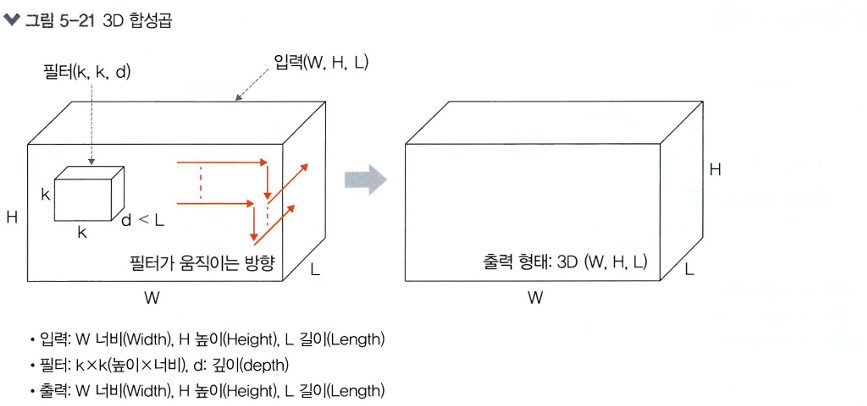

**3D 입력을 갖는 2D 합성곱**

입력이 3D 형태임에도 출력 형태가 2D 행렬을 취하는 것이 '3D 입력을 갖는 2D 합성곱'이다. 이것은 필터에 대한 길이가 입력 채널의 길이와 같아야 하기 때문에 이와 같은 합성곱 형태가 만들어진다. 즉, 입력 (W,H,L)에 필터 (k,k,L)를 적용하면 출력은 (W,H)가 된다. 이때, 필터는 다음 그림과 같이 두 방향으로 움직인다.

대표적인 사례로는 LeNet-5와 VGG가 있다.

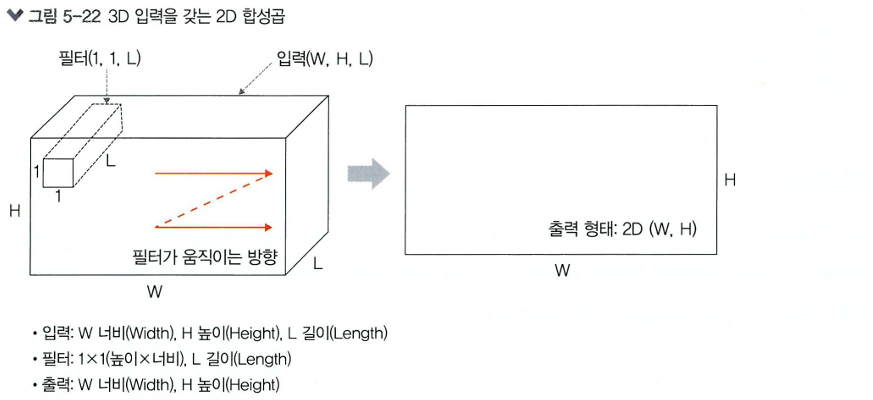

**1X1 합성곱**

1X1 합성곱은 3D 형태로 입력된다. 즉, 입력 (W,H,L)에 필터(1,1,L)를 적용하면 출력은(W,H)가 된다. 1X1 합성곱에서 채널 수를 조정해서 연산량이 감소되는 효과가 있으며, 대표적 사례로는 GoogLeNet이 있다.

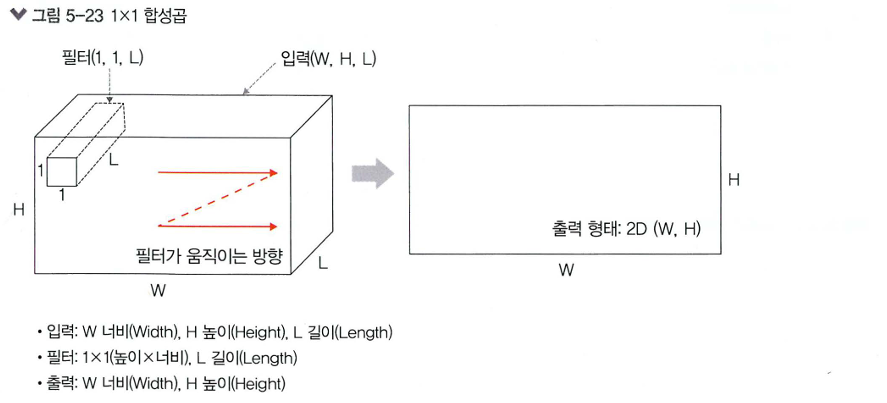